In [2]:
import pandas as pd
from pathlib import Path

In [3]:
data_path = '/Users/joanameyer/data/asic/mock_data'
dynamic_filepath = Path(data_path) / 'dynamic.parquet'
dynamic = pd.read_parquet(dynamic_filepath) 

static_filepath = Path(data_path) / 'static.parquet'
static = pd.read_parquet(static_filepath)

In [4]:
dynamic[['Pseudo-ID','timeidx', 'Zeit_ab_Aufnahme']].dtypes

Pseudo-ID                   object
timeidx             datetime64[us]
Zeit_ab_Aufnahme           float32
dtype: object

In [5]:
unique_stays = dynamic['Pseudo-ID'].unique()

for stay in unique_stays[:3]:
    display(dynamic[dynamic['Pseudo-ID'] == stay][['Pseudo-ID','timeidx', 'Zeit_ab_Aufnahme']])

,Pseudo-ID,timeidx,Zeit_ab_Aufnahme
0,53:0,2020-01-01 00:00:00,0.0
1,53:0,2020-01-01 00:15:00,15.0
2,53:0,2020-01-01 00:30:00,30.0
3,53:0,2020-01-01 00:45:00,45.0
4,53:0,2020-01-01 01:00:00,60.0
...,...,...,...
626,53:0,2020-01-07 12:30:00,9390.0
627,53:0,2020-01-07 12:45:00,9405.0
628,53:0,2020-01-07 13:00:00,9420.0
629,53:0,2020-01-07 13:15:00,9435.0


,Pseudo-ID,timeidx,Zeit_ab_Aufnahme
631,57:0,2020-01-01 00:00:00,0.0
632,57:0,2020-01-01 00:15:00,15.0
633,57:0,2020-01-01 00:30:00,30.0
634,57:0,2020-01-01 00:45:00,45.0
635,57:0,2020-01-01 01:00:00,60.0
...,...,...,...
9705,57:0,2020-04-04 12:30:00,136110.0
9706,57:0,2020-04-04 12:45:00,136125.0
9707,57:0,2020-04-04 13:00:00,136140.0
9708,57:0,2020-04-04 13:15:00,136155.0


,Pseudo-ID,timeidx,Zeit_ab_Aufnahme
9710,20:0,2020-01-01 00:00:00,0.0
9711,20:0,2020-01-01 00:15:00,15.0
9712,20:0,2020-01-01 00:30:00,30.0
9713,20:0,2020-01-01 00:45:00,45.0
9714,20:0,2020-01-01 01:00:00,60.0
...,...,...,...
10084,20:0,2020-01-04 21:30:00,5610.0
10085,20:0,2020-01-04 21:45:00,5625.0
10086,20:0,2020-01-04 22:00:00,5640.0
10087,20:0,2020-01-04 22:15:00,5655.0


In [6]:
print(static[['KH-Sterblichkeit', 'Sterblichkeit']].dtypes)
print(static['KH-Sterblichkeit'].unique())
print(static['Sterblichkeit'].unique())
static[['KH-Sterblichkeit', 'Sterblichkeit']]

KH-Sterblichkeit    object
Sterblichkeit       object
dtype: object
['false' 'true' None]
['nan' '0' 'ICU' None 'KH']


,KH-Sterblichkeit,Sterblichkeit
0,false,nan
1,true,nan
2,true,nan
3,false,nan
4,false,nan
...,...,...
695,None,ICU
696,None,0
697,None,0
698,None,KH


In [7]:
dynamic_columns = dynamic.columns
# Find columns with sofa in name
sofa_columns = [col for col in dynamic_columns if 'sofa' in col.lower()]
sofa_columns


['Organversagen:_SOFA_Score_ohne_GCS',
 'SOFA',
 'SOFA.Punkte_Blut',
 'SOFA.Punkte_Leber',
 'SOFA.Punkte_Lunge',
 'SOFA.Punkte_Lunge_(cal.)',
 'SOFA.Punkte_Niere',
 'SOFA.Punkte_ZNS',
 'SOFA.SOFA_Gesamt',
 'iSOFA.HKL',
 'iSOFA.Leber',
 'iSOFA.Lunge',
 'iSOFA.Niere',
 'iSOFA.Thrombo',
 'iSOFA.ZNS',
 'iSOFA.iSOFA_Gesamt']

In [8]:
dynamic[sofa_columns].dropna(how='all')

,Organversagen:_SOFA_Score_ohne_GCS,SOFA,SOFA.Punkte_Blut,SOFA.Punkte_Leber,SOFA.Punkte_Lunge,SOFA.Punkte_Lunge_(cal.),SOFA.Punkte_Niere,SOFA.Punkte_ZNS,SOFA.SOFA_Gesamt,iSOFA.HKL,iSOFA.Leber,iSOFA.Lunge,iSOFA.Niere,iSOFA.Thrombo,iSOFA.ZNS,iSOFA.iSOFA_Gesamt
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,2.0,0.0,0.0,0.0,5.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,3.0,1.0,0.0,0.0,15.0
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,0.0,1.0,4.0,11.0
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,3.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524355,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524451,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524547,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
524643,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
static.columns

Index(['Pseudo-ID', 'Cluster-ID', 'Zeit_seit_Studienbeginn', 'Phase',
       'clusterGeschlecht', 'clusterKoerpergewicht', 'clusterKoerpergroesse',
       'BMI', 'Liegedauer_KH', 'Liegedauer_ICU', 'Wiederaufnahme_ICU',
       'clusterAlter',
       'Entlassgrund_(verlegt_intern,_verlegt_extern,_verstorben)',
       'Sterblichkeit', 'ICD-10_Codes', 'weightKg', 'heightcm',
       'KH-Sterblichkeit', 'hid', 'Dialyse_(dialysefreie_Tage)',
       'Beatmungsfreie_Tage'],
      dtype='object')

In [10]:
static.hid.unique()

array([0., 2., 3., 4., 6., 7., 8.])

In [14]:
delta_columns = [col for col in dynamic_columns if 'delta' in col.lower()]
delta_columns

['DeltaP', 'deltaP']

In [20]:
dynamic[delta_columns].dropna(how='all').isna().value_counts()

DeltaP  deltaP
False   False     172982
        True      150699
True    False       6211
Name: count, dtype: int64

In [22]:
dynamic[['Pseudo-ID']+ delta_columns].dropna(how='any')

,Pseudo-ID,DeltaP,deltaP
22034,7:0,-6.118297,16.000
336932,39:3,12.331000,9.388
336934,39:3,12.864001,9.187
336936,39:3,7.691000,8.872
336937,39:3,6.845000,12.576
...,...,...,...
956318,7:7,7.520000,8.770
956319,7:7,8.700001,11.670
956320,7:7,6.430000,8.600
956321,7:7,6.160000,13.670


In [11]:
dynamic[['pH_Wert_(ohne_Temp-Korrektur)_arteriell', 'pH_arteriell']].dropna(how='all').describe()

,pH_Wert_(ohne_Temp-Korrektur)_arteriell,pH_arteriell
count,17823.000000,42301.000000
mean,7.420352,7.434221
std,0.104588,5.080488
min,0.000000,0.000000
25%,7.385000,7.370000
50%,7.434000,7.429000
75%,7.470000,7.465000
max,7.732000,747.000000


In [8]:
dynamic[['hid', 'pH_Wert_(ohne_Temp-Korrektur)_arteriell']].groupby('hid').agg(['count'])

,pH_Wert_(ohne_Temp-Korrektur)_arteriell
,count
hid,
0,17823
2,0
3,0
4,0
6,0
7,0
8,0


In [16]:
dynamic[['hid', 'pH_arteriell']].groupby('hid').agg(['count', 'mean', 'std', 'median', 'min', 'max'])

pH_arteriell                                            
           count      mean        std median    min      max
hid                                                         
0              0       NaN        NaN    NaN    NaN      NaN
2              0       NaN        NaN    NaN    NaN      NaN
3          10284  7.353317   0.122016  7.383  6.678    7.681
4           7217  7.644437  12.285799  7.446  7.115  747.000
6              0       NaN        NaN    NaN    NaN      NaN
7          14598  7.393849   0.369840  7.420  0.000    7.680
8          10202  7.424832   0.083213  7.440  6.790    7.660

(array([4.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 4.000e+00,
        4.000e+00, 4.000e+00, 1.100e+01, 1.100e+01, 1.900e+01, 2.300e+01,
        4.400e+01, 5.400e+01, 8.300e+01, 8.500e+01, 1.230e+02, 1.530e+02,
        2.250e+02, 3.130e+02, 4.320e+02, 5.800e+02, 7.060e+02, 9.050e+02,
        1.114e+03, 1.367e+03, 1.829e+03, 2.096e+03, 2.259e+03, 2.033e+03,
        1.478e+03, 9.110e+02, 4.220e+02, 2.390e+02, 1.110e+02, 7.200e+01,
        3.700e+01, 2.200e+01, 1.200e+01, 6.000e+00, 6.000e+00, 4.000e+00,
        5.000e+00, 1.000e+00]),
 array([6.83300018, 6.85098028, 6.86896038, 6.88694   , 6.9049201 ,
        6.9229002 , 6.9408803 , 6.95885992, 6.97684002, 6.99482012,
        7.01280022, 7.03078032, 7.04875994, 7.06674004, 7.08472013,
        7.10270023, 7.12067986, 7.13865995, 7.15664005, 7.17462015,
        7.19260025, 7.21057987, 7.22855997, 7.24654007, 7.26452017,
        7.28250027, 7.30047989, 7.31

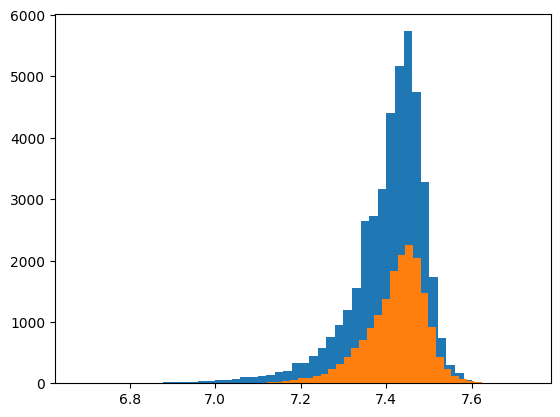

In [44]:
x = dynamic[(dynamic.pH_arteriell>5) & (dynamic.pH_arteriell<100)].pH_arteriell
ycol = 'pH_Wert_(ohne_Temp-Korrektur)_arteriell'
y = dynamic[(dynamic[ycol]>5) & (dynamic[ycol]<100)][ycol]
# plot histogram of x and y
import matplotlib.pyplot as plt
plt.hist(x, bins=50)
plt.hist(y, bins=50)

In [39]:
y

Series([], Name: pH_Wert_(ohne_Temp-Korrektur)_arteriell, dtype: float32)

In [ ]:
dynamic[['Pseudo']'pH_Wert_(ohne_Temp-Korrektur)_arteriell'].dropna()

8         7.4400
20        7.4500
30        7.3190
32        7.4420
56        7.4600
           ...  
175109    7.4380
175139    7.2920
175259    7.4220
175300    7.3220
175303    7.2775
Name: pH_Wert_(ohne_Temp-Korrektur)_arteriell, Length: 17823, dtype: float32

In [66]:
static.Sterblichkeit.unique()

array(['nan', '0', 'ICU', None, 'KH'], dtype=object)